<a href="https://colab.research.google.com/github/Rajeshsivamoorthy/DSSP-PLOT/blob/main/DSSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files
uploaded = files.upload()

# ==============================
# Convert .dat to .txt (clean)
# ==============================

import os

# 🔧 Get uploaded file name
input_file = list(uploaded.keys())[0]
output_file = input_file.replace(".dat", ".txt")

clean_lines = []

with open(input_file, 'r') as f:
    for line in f:
        # ❌ Skip comments
        if line.startswith('#') or line.startswith('@'):
            continue
        # ✔ Keep valid data
        line = line.strip()
        if line:
            clean_lines.append(line)

# 💾 Save cleaned file
with open(output_file, 'w') as f:
    for line in clean_lines:
        f.write(line + '\n')

print(f"✅ Conversion completed: {output_file}")

files.download(output_file)

Saving dssp.dat to dssp.dat
✅ Conversion completed: dssp.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Enter output file type (png, tif, pdf, jpg): tif
Enter DPI value (300, 600, 900): 300
Plot saved as 'DSSP_single.tif' with 300 DPI.


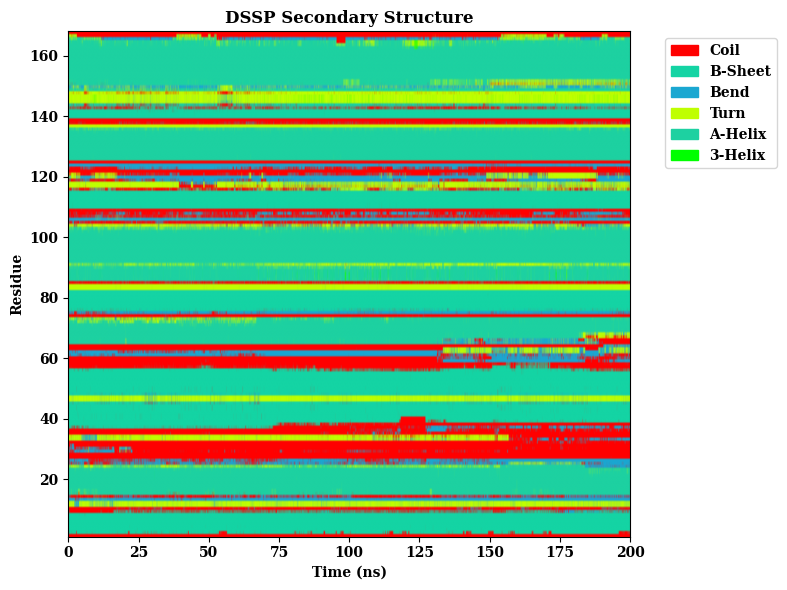

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Single DSSP plot generated successfully!


In [33]:
# ==============================
# SINGLE DSSP PLOT (FINAL)
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set font globally for all text elements to Times New Roman and bold
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Input file
input_file = list(uploaded.keys())[0]

# ==============================
# DSSP Mapping
# ==============================
dssp_map = {
    '=': 0, '~': 0,   # Coil
    'E': 1, 'B': 1,   # Beta sheet
    'S': 2,           # Bend
    'T': 3,           # Turn
    'H': 4,           # Alpha helix
    'G': 5, 'I': 5    # 3-10 helix
}

# ==============================
# Colors (your legend)
# ==============================
colors = [
    "#ff0000",  # Coil
    "#14d4a4",  # B-sheet
    "#1aa7d1",  # Bend
    "#bfff00",  # Turn
    "#1dd1a1",  # A-Helix
    "#00ff00"   # 3-Helix
]

cmap = ListedColormap(colors)

# ==============================
# Read DSSP file
# ==============================
data = []

with open(input_file, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith(('@', '#')):
            continue
        row = [dssp_map.get(c, 0) for c in line]
        data.append(row)

data = np.array(data)   # shape = (frames, residues)

# ==============================
# Axes setup
# ==============================
frames = data.shape[0]
residues = data.shape[1]

time = np.linspace(0, 200, frames)  # adjust if needed

# ==============================
# Plot
# ==============================
fig, ax = plt.subplots(figsize=(8, 6)) # Changed figsize to make the plot square

im = ax.imshow(data.T,
               aspect='auto',
               cmap=cmap,
               origin='lower',
               extent=[time[0], time[-1], 1, residues])

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Residue")
ax.set_title("DSSP Secondary Structure")

# ==============================
# Legend
# ==============================
legend_elements = [
    mpatches.Patch(color=colors[0], label='Coil'),
    mpatches.Patch(color=colors[1], label='B-Sheet'),
    mpatches.Patch(color=colors[2], label='Bend'),
    mpatches.Patch(color=colors[3], label='Turn'),
    mpatches.Patch(color=colors[4], label='A-Helix'),
    mpatches.Patch(color=colors[5], label='3-Helix')
]

ax.legend(handles=legend_elements,
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          prop={'family': 'DejaVu Serif', 'weight': 'bold'})

plt.tight_layout()

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (png, tif, pdf, jpg): ").strip().lower()
dpi_value_str = input("Enter DPI value (300, 600, 900): ").strip()

valid_save_types = ['png', 'pdf', 'svg', 'jpg', 'jpeg', 'tif']

if file_type not in valid_save_types:
    print("Invalid type. Defaulting to png.")
    file_type = 'png'

try:
    dpi_value = int(dpi_value_str)
except ValueError:
    print("Invalid DPI value. Defaulting to 300.")
    dpi_value = 300

# Save
output_filename = f"DSSP_single.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')
print(f"Plot saved as '{output_filename}' with {dpi_value} DPI.")
plt.show()

files.download(output_filename)

print("✅ Single DSSP plot generated successfully!")